In [10]:
import pygimli as pg 
import matplotlib.pyplot as plt
import numpy as np
from pygimli.physics import ert
import pygimli.meshtools as mt
from scipy.interpolate import griddata
import pandas as pd
import os 
output_dir = "investigation1"
os.makedirs(output_dir, exist_ok=True)


25/03/26 - 15:03:01 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 
25/03/26 - 15:03:01 - pyGIMLi - INFO - Cache c:\Users\sider\.conda\envs\pg\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (0.0s x 101): C:\Users\sider\AppData\Roaming\pygimli\Cache\17970140561219481632


Data: Sensors: 21 data: 171, nonzero entries: ['a', 'b', 'k', 'm', 'n', 'valid']


25/03/26 - 15:03:02 - pyGIMLi - INFO - Data error estimate (min:max)  0.05000454074533492 : 0.06811587476498343
25/03/26 - 15:03:02 - pyGIMLi - INFO - 0.6713075487983402 1315.0811231422217
25/03/26 - 15:03:02 - pyGIMLi - INFO - Simulated data:  Data: Sensors: 21 data: 171, nonzero entries: ['a', 'b', 'err', 'i', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']
25/03/26 - 15:03:02 - pyGIMLi - INFO - The data contains :  ['a', 'b', 'err', 'i', 'ip', 'iperr', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']
25/03/26 - 15:03:02 - pyGIMLi - INFO - Sim rhoa (min/max) :  20.365704526008784 152.62263493556281
25/03/26 - 15:03:02 - pyGIMLi - INFO - Selected data noise % (min/ma)x :  5.000454074533492 6.811587476498343
25/03/26 - 15:03:02 - pyGIMLi - INFO - filtered rhoa minmax dd :  20.365704526008784 152.62263493556281


relativeError set to a value > 0.5 .. assuming this is a percentage Error level dividing them by 100


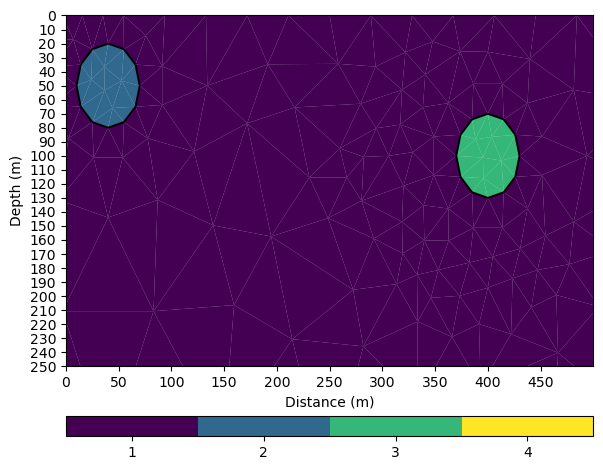

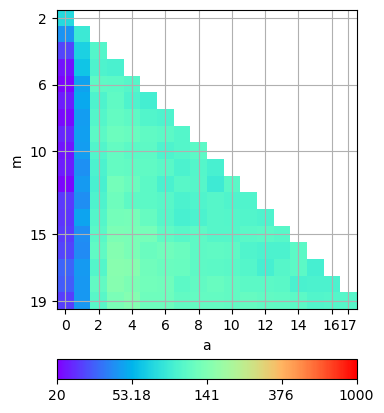

In [18]:
world=mt.createWorld(start=[-1000,0],end=[1500,-1000],worldMarker=1)

body1=mt.createCircle(pos=[40,-50],radius=30,marker=2)
body2=mt.createCircle(pos=[400,-100],radius=30,marker=3)
geom=world+body1+body2

#pg.show(geom,showMesh=True,quality=34)

mesh_cut = mt.createMesh(geom, quality=34)

x_min,x_max= 0,500
y_min,y_max= -250,0

ax, cbar = pg.show(mesh_cut, data=mesh_cut.cellMarkers(), 
                   showMesh=False, aspect='auto', 
                   cmap=plt.get_cmap("viridis", 4), cbar=True)
cbar.mappable.set_clim(0.5, 4.5)
cbar.set_ticks([1, 2, 3, 4])

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_yticks(np.arange(y_min, 1, 10)) 
ax.set_xticks(np.arange(x_min, x_max, 50)) 
ax.set_xlabel("Distance (m)")   
ax.set_ylabel("Depth (m)")
ax.figure.savefig(os.path.join(output_dir, f'mesh_cut.png'))
plt.draw()

spacing=25
scheme=ert.createData(
    elecs=np.linspace(start=0,stop=500,num=len(np.arange(0,501,spacing)))
    , schemeName='dd'
)
print(scheme)
for p in scheme.sensors():
    geom.createNode(p)
    geom.createNode(p-[0,0.1]) # create 2  nodes for FTDT
mesh_fwr=mt.createMesh(geom,quality=34)
rhomap=[[1,100],
        [2,1],
        [3,1000]]
#pg.show(mesh_fwr,data=rhomap,label=pg.unit('res'), cMap='rainbow',logScale=True,aspect='auto')


data=ert.simulate(mesh_fwr,scheme=scheme, res=rhomap, noiseLevel=5, noiseAbs=1e-6, seed=1337)

pg.info(np.linalg.norm(data['err']),np.linalg.norm(data['rhoa']))
pg.info('Simulated data: ',data)
pg.info('The data contains : ',data.dataMap().keys())
pg.info('Sim rhoa (min/max) : ' ,min(data['rhoa']), max(data['rhoa']))
pg.info('Selected data noise % (min/ma)x : ', min(data['err'])*100, max(data['err'])*100)

data.remove(data['rhoa']<0)
pg.info('filtered rhoa minmax dd : ', min(data['rhoa']), max(data['rhoa']))

data.save(os.path.join(output_dir, f'{output_dir}_dd.dat'))

#ert.show(data,cMap='rainbow',cMin=20,cMax=1000,logScale=True,title='DD')   #pseudosection
pg.viewer.mpl.showDataContainerAsMatrix(data,'a','m', 'rhoa',cMap='rainbow',cMin=20,cMax=1000,logScale=True,title='DD')

np.save(os.path.join(output_dir, f'{output_dir}_abmn_dd.npy'), np.column_stack([data['a'], data['b'], data['m'], data['n']]))
np.save(os.path.join(output_dir, f'{output_dir}_res_all_dd.npy'), np.column_stack([data['rhoa']]))
abmn_data_dd = np.load(os.path.join(output_dir, f'{output_dir}_abmn_dd.npy'))
res_data_dd=np.load(os.path.join(output_dir, f'{output_dir}_res_all_dd.npy'))

In [19]:
def fill_nan(image):
    image=image.copy()
    nan_mask = np.isnan(image)
    mean_value = np.nanmean(image)
    image[nan_mask] = mean_value
    return image, nan_mask
def compress(image, n_singular_values, n_pixels, z_factor): 
    image, nan_mask = fill_nan(image)
    U, S, Vt = np.linalg.svd(image, full_matrices=False)
    U_reduced = U[:,:n_singular_values]
    S_reduced = np.diag(S[:n_singular_values])
    Vt_reduced = Vt[:n_singular_values,:]
    compressed_image = np.dot(U_reduced, np.dot(S_reduced, Vt_reduced))    
    contributions = np.abs(U_reduced) @ np.abs(Vt_reduced)
    
    # Apply depth weighting to contributions
    rows, cols = np.arange(image.shape[0]), np.arange(image.shape[1])
    z = rows / np.max(rows)
    depth_weight = 1 + z_factor * z   
    depth_weight = depth_weight[:, None]
    contributions *= depth_weight

    contributions[nan_mask] = -np.inf

    #anchor points
    #first column (idx= 0)
    valid_rows_0 = np.flatnonzero(~nan_mask[:, 0])
    if valid_rows_0.size > 0:
        rows_min, rows_max, rows_mean = valid_rows_0[0], valid_rows_0[-1],valid_rows_0[valid_rows_0.size // 2]
        contributions[rows_min, 0],contributions[rows_max, 0], contributions[rows_mean, 0] = np.inf, np.inf, np.inf
    
    #set last column first row contribution to inf
    valid_cols= np.where(~nan_mask)[1]
    if valid_cols.size > 0:
        col_last = valid_cols.max()
        valid_rows_in_last_col = np.flatnonzero(~nan_mask[:, col_last])
        if valid_rows_in_last_col.size > 0:
            row_last = valid_rows_in_last_col[0]
            contributions[row_last, col_last] = np.inf

        unique_cols = np.unique(valid_cols)
        col_mean = unique_cols[unique_cols.size // 2]
        valid_rows_in_mean_col = np.flatnonzero(~nan_mask[:, col_mean])
        if valid_rows_in_mean_col.size > 0:
            contributions[valid_rows_in_mean_col[-1], col_mean] = np.inf

    flat_indices = np.argsort(contributions.flatten())[::-1][:n_pixels]
    significant_indices = np.unravel_index(flat_indices, image.shape)

    return compressed_image, significant_indices, nan_mask, contributions
def reconstruct(image_shape, significant_indices, pixel_values):
    # Create an empty image with the given shape
    compressed_image = np.full(image_shape, np.nan)
    # Assign the provided pixel values to the significant indices
    compressed_image[significant_indices] = pixel_values
    # Interpolate to fill in the missing values
    x, y = np.meshgrid(np.arange(image_shape[1]), np.arange(image_shape[0]))
    mask = ~np.isnan(compressed_image)
    interpolated_image = griddata(
        (x[mask], y[mask]),  # Points with known values
        compressed_image[mask],  # Known values
        (x, y),  # Points to interpolate
        method='linear'  # Interpolation 
        )
    return interpolated_image
def plot_ert_checkerboard(data,plot=0):
    #Extract unique electrode positions
    electrodes = np.unique(data[['A', 'B', 'M', 'N']].values)
    electrode_map = {electrode: idx for idx, electrode in enumerate(sorted(electrodes))}
    #Create a grid
    grid_size = len(electrode_map)
    heatmap = np.full((grid_size, grid_size), np.nan)
    #Map values to the grid
    for _, row in data.iterrows():
        x = electrode_map[row['A']]
        y = electrode_map[row['M']]
        heatmap[y, x] = row['Res']
    if plot==1:
        #Plot the checkerboard heatmap
        plt.figure(figsize=(10, 8))
        plt.imshow(np.log10(heatmap), cmap='gist_rainbow', interpolation='nearest')
        plt.colorbar(label='ERT Measurement Value')
        plt.xticks(ticks=np.arange(grid_size), labels=sorted(electrode_map.keys()), rotation=90)
        plt.yticks(ticks=np.arange(grid_size), labels=sorted(electrode_map.keys()))
        plt.xlabel('Electrode A')
        plt.ylabel('Electrode N')
        plt.title('ERT Checkerboard Heatmap')
        plt.savefig(os.path.join(output_dir, f'{output_dir}_checkerboard_heatmap.png'))
        plt.close()
    return heatmap

In [20]:
abmn_data=np.load(os.path.join(output_dir, f'{output_dir}_abmn_dd.npy'))
res_data=np.load(os.path.join(output_dir, f'{output_dir}_res_all_dd.npy'))
data_all=np.column_stack((abmn_data, res_data))
data=pd.DataFrame(data_all, columns=['A', 'B', 'M', 'N', 'Res'])
image=plot_ert_checkerboard(data,plot=1)

n_singular_values=21
n_pixels=image[~np.isnan(image)].size
z_factor=0

compressed_image, significant_indices, nan_mask, contributions = compress(image, n_singular_values, n_pixels, z_factor)
pixel_values = compressed_image[significant_indices]
real_values = image[significant_indices]
reconstructed_image = reconstruct(image.shape, significant_indices, pixel_values)
predicted_values = reconstructed_image[significant_indices]

for i in range(21):
    n_singular_values = i + 1
    compressed_image, significant_indices, nan_mask, contributions = compress(image, n_singular_values, n_pixels, z_factor)
    plt.imshow(contributions, cmap='binary')
    plt.savefig(os.path.join(output_dir, f'contributions_{n_singular_values}_{z_factor:.2f}.png'))
    plt.close()

In [21]:
n_pixels_max=image[~np.isnan(image)].size
k=21
results =[]

for i in range(1,k+1):
    for j in range(n_pixels_max, 10, -10):
        compressed_image, significant_indices, nan_mask, contributions = compress(image, n_singular_values=i, n_pixels=j, z_factor=z_factor)
        pixel_values = compressed_image[significant_indices]
        reconstructed_image = reconstruct(image.shape, significant_indices, pixel_values)
        predicted_values = reconstructed_image[significant_indices]
        valid_mask = ~np.isnan(image)
        rmse=np.sqrt(np.nanmean((image[valid_mask] - reconstructed_image[valid_mask]) ** 2))
        results.append(({ 'singular_values': i, 'pixels': j, 'rmse': rmse }))   #dictionary

rmse_df = pd.DataFrame(results)
rmse_df.to_csv(os.path.join(output_dir, 'rmse_results.csv'), index=False)
for n in range(1,k+1):
    df_k = rmse_df[rmse_df['singular_values'] == n].sort_values(by='pixels', ascending=False)
    plt.figure(figsize=(8, 5))
    plt.plot(df_k['pixels'], df_k['rmse'], marker='o', color='b')
    plt.gca().invert_xaxis()
    plt.xlabel("Number of Pixels")
    plt.ylabel("RMSE")
    plt.title(f"RMSE vs Decreasing Pixels (Rank k={n})")
    plt.grid(True)
    plt.ylim(top=20, bottom=0)    
    plt.savefig(os.path.join(output_dir, f'rmse_k_{n}.png'))
    plt.close()

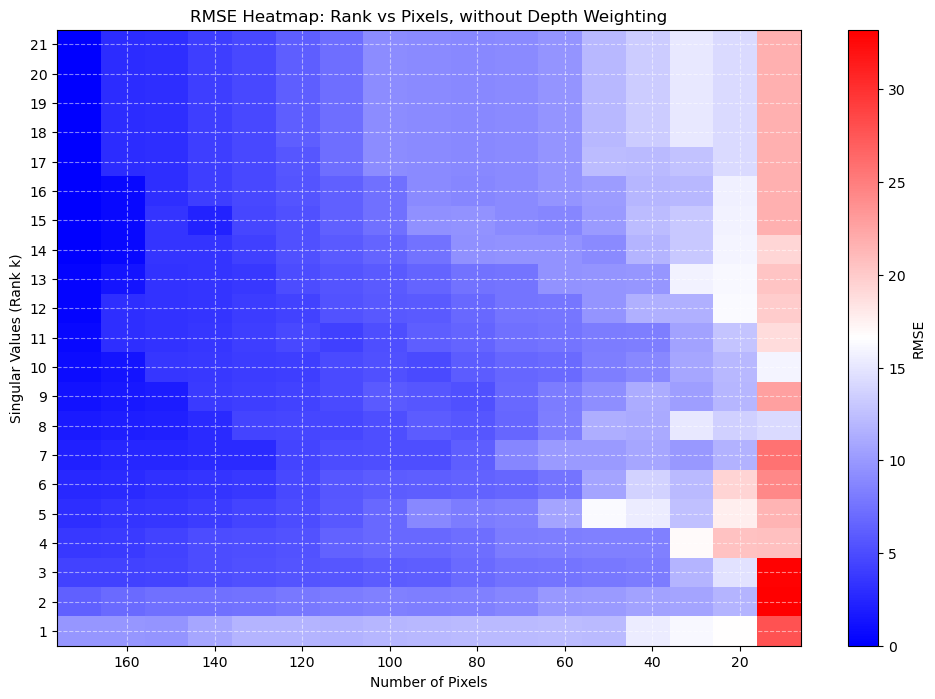

In [ ]:

heatmap_data = rmse_df.pivot(index='singular_values', columns='pixels', values='rmse')

plt.figure(figsize=(12, 8))
mesh = plt.pcolormesh(heatmap_data.columns, heatmap_data.index, heatmap_data.values, 
                      cmap='bwr', shading='auto')

plt.colorbar(mesh, label='RMSE')

plt.gca().invert_xaxis()

plt.xlabel("Number of Pixels")
plt.ylabel("Singular Values (Rank k)")
plt.title("RMSE Heatmap: Rank vs Pixels, without Depth Weighting")
plt.yticks(np.arange(1, k + 1, 1))  
plt.grid(color='white', linestyle='--', alpha=0.5)
plt.savefig(os.path.join(output_dir, f'rmse_heatmap.png'))
plt.show()

In [23]:
z_factors=np.arange(0,0.65,0.05)
results3d=[]
for z in z_factors:
    print(f"Processing z_factor: {z:.2f}")
    for l in range(1,k+1):
        for b in range(n_pixels_max, 10, -10):
            compressed_image, significant_indices, nan_mask, contributions = compress(image, n_singular_values=l, n_pixels=b, z_factor=z)
            pixel_values = compressed_image[significant_indices]
            reconstructed_image = reconstruct(image.shape, significant_indices, pixel_values)
            valid_mask = ~np.isnan(image)
            rmse=np.sqrt(np.nanmean((image[valid_mask] - reconstructed_image[valid_mask]) ** 2))
            results3d.append(({ 'singular_values': l, 'pixels': b, 'z_factor': z, 'rmse': rmse }))   #dictionary

df_3d = pd.DataFrame(results3d)
df_3d.to_csv(os.path.join(output_dir, 'rmse_results_3d.csv'), index=False)


Processing z_factor: 0.00
Processing z_factor: 0.05
Processing z_factor: 0.10
Processing z_factor: 0.15
Processing z_factor: 0.20
Processing z_factor: 0.25
Processing z_factor: 0.30
Processing z_factor: 0.35
Processing z_factor: 0.40
Processing z_factor: 0.45
Processing z_factor: 0.50
Processing z_factor: 0.55
Processing z_factor: 0.60


In [24]:
for n in range(1, k + 1):
    best_z = df_3d[df_3d['singular_values'] == n].sort_values(by='rmse').iloc[0]['z_factor']
    
    df_k = df_3d[(df_3d['singular_values'] == n) & (df_3d['z_factor'] == best_z)].sort_values(by='pixels', ascending=False)
    
    plt.figure(figsize=(8, 5))
    plt.plot(df_k['pixels'], df_k['rmse'], marker='o', color='b', label=f'z_factor = {best_z:.2f}')
    
    plt.gca().invert_xaxis()
    plt.xlabel("Number of Pixels")
    plt.ylabel("RMSE")
    plt.title(f"RMSE vs Decreasing Pixels (Rank k={n}, Best z={best_z:.2f})")
    plt.legend()
    plt.grid(True)
    plt.ylim(top=20, bottom=0)    
    
    plt.savefig(os.path.join(output_dir, f'rmse_k_{n}_best_z.png'))
    plt.close()


'''seems like weighting doesnt improve results in higher ranks, changes in some smaller ranks, could be overfitting.'''

'seems like weighting doesnt improve results in higher ranks, changes in some smaller ranks, could be overfitting.'